In [1]:
import os
import json
import yaml
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def read_config(file_path):
    with open(file_path, 'r') as file:
        return yaml.safe_load(file)

def is_config_valid(config, ref_config, ignore_fields):
    for key, value in ref_config.items():
        if key not in ignore_fields and config.get(key) != value:
            print(key, config.get(key))
            return False
    return True

def valid_directories(search_path, ref_config, config_ignore_fields):
    valid_dirs = []
    for directory in os.listdir(search_path):
        dir_path = os.path.join(search_path, directory)
        config_path = os.path.join(dir_path, 'config.yaml')
        if os.path.isfile(config_path):
            config = read_config(config_path)
            if (ref_config is None) or is_config_valid(config, ref_config, config_ignore_fields):
                valid_dirs.append(directory)
            else:
                print(directory)
    return valid_dirs

def read_epochs_data(file_path):
    with open(file_path, 'r') as file:
        return [json.loads(line) for line in file]

def is_run_valid(epoch_data, min_epoch,require_finish_flag=True, finish_flag=None):
    if require_finish_flag:
        return len(epoch_data) >= min_epoch and os.path.isfile(finish_flag)
    else:
        return len(epoch_data) >= min_epoch

def aggregate_results(valid_dirs, min_epoch, search_path, use_test):
    all_results = {}
    all_configs ={}
    for dir_name in valid_dirs:
        dir_path = os.path.join(search_path, dir_name)
        if use_test:
            results_path = os.path.join(dir_path, 'results', 'test_data.json')
            min_epoch = 0
        else:
            results_path = os.path.join(dir_path, 'results', 'epoch_data.json')
        config_path = os.path.join(dir_path, 'config.yaml')
        if os.path.isfile(results_path):
            epoch_data = read_epochs_data(results_path)
            if is_run_valid(epoch_data, 
                            min_epoch, 
                            require_finish_flag=True, 
                            finish_flag = os.path.join(dir_path,'run_finished')):
#             if  os.path.isfile(os.path.join(dir_path,'run_finished')):
                dir_results = {}
                for epoch in epoch_data:
                    for key, value in epoch.items():
                        if key not in dir_results:
                            dir_results[key] = []
                        dir_results[key].append(value)
                all_results[dir_name] = dir_results
                all_configs[dir_name] = read_config(config_path)
            else:
                print(dir_name)
        else:
             print(dir_name)
    return all_results, all_configs

# Main function
def analyze_runs(ref_config_path, search_path, config_ignore_fields, min_epoch, use_test):
    ref_config = read_config(ref_config_path) if ref_config_path is not None else None
    valid_dirs = valid_directories(search_path, ref_config, config_ignore_fields)
    print(len(valid_dirs))
    return aggregate_results(valid_dirs, min_epoch, search_path, use_test)

def mean_k_last_result(result_dicts,key,k_last, as_dict=False):
    results = {} if as_dict else []
    for run_name, result_dict in result_dicts.items():
        if key in result_dict.keys():
            this_result = np.mean(result_dict[key][-k_last:])
            if as_dict:
                results[run_name] = this_result
            else:
                results.append(this_result)
        else:
            print(f'warning, no such a field in run name:{run_name}')
    return results


def df_to_latex_table(df: pd.DataFrame, new_column_names: dict = None, column_formats: dict = None, default_format: str = ".3f") -> str:
    """
    Convert a pandas DataFrame to a LaTeX table string with optional column renaming, formatting, and multi-line headers.
    
    Parameters:
        df (pd.DataFrame): The DataFrame to convert.
        new_column_names (dict, optional): A dictionary to rename columns. 
                                           Format: {'old_name': 'new_name'}.
        column_formats (dict, optional): A dictionary specifying format for columns.
                                         Format: {'column_name': 'format_specifier'}.
                                         Example: {'A': '.2f', 'B': 'd'}.
        default_format (str, optional): Default formatting for numeric values. Defaults to '.3f'.
                                           
    Returns:
        str: Full LaTeX code for the table.
    """
    def try_convert_to_number(value):
        """Try to convert a value to a number if it looks like one."""
        try:
            return float(value) if '.' in str(value) else int(value)
        except ValueError:
            return value

    def format_header(header):
        """Format a column header to split long text into multiple lines using \makecell."""
        return "\\makecell{" + " \\\\ ".join(header.split()) + "}"

    # Rename columns if new_column_names is provided
    if new_column_names:
        df = df.rename(columns=new_column_names)
    
    # Apply formatting to columns if column_formats is provided
    formatted_df = df.copy()
    for col in formatted_df.columns:
        if column_formats and col in column_formats:
            fmt = column_formats[col]
        else:
            fmt = default_format  # Use default format for unspecified columns
        
        formatted_df[col] = formatted_df[col].apply(
            lambda x: f"{try_convert_to_number(x):{fmt}}" 
                      if pd.notnull(x) and isinstance(try_convert_to_number(x), (int, float)) 
                      else x
        )
    
    # Start the LaTeX table
    latex_code = "\\begin{table}[ht]\n\\centering\n"
    latex_code += "\\begin{tabular}{" + " | ".join(["c"] * len(formatted_df.columns)) + "}\n"
    latex_code += "\\hline\n"
    
    # Add column headers with multi-line formatting
    formatted_headers = [format_header(header) for header in formatted_df.columns]
    latex_code += " & ".join(formatted_headers) + " \\\\\n"
    latex_code += "\\hline\n"
    
    # Add rows
    for _, row in formatted_df.iterrows():
        latex_code += " & ".join(map(str, row)) + " \\\\\n"
        latex_code += "\\hline\n"
    
    # End the LaTeX table
    latex_code += "\\end{tabular}\n"
    latex_code += "\\caption{Your table caption here.}\n"
    latex_code += "\\label{tab:your_label_here}\n"
    latex_code += "\\end{table}"
    
    return latex_code


<>:119: SyntaxWarning: invalid escape sequence '\m'
<>:119: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_619781/3091725536.py:119: SyntaxWarning: invalid escape sequence '\m'
  """Format a column header to split long text into multiple lines using \makecell."""


In [2]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def add_inset_with_symbols(ax, width="30%", height="30%", loc=1, 
                           styles=None, titles = None, 
                           bbox=(0.5, 0.5, 0.5, 0.5)):
    """
    Add an inset to the given axis with symbols and their meanings.

    Parameters:
    ax (matplotlib.axes.Axes): The axis to add the inset to.
    width (str): Width of the inset as a percentage of the parent axis.
    height (str): Height of the inset as a percentage of the parent axis.
    loc (int): Location code for the inset (1=upper right, 2=upper left, etc.).
    """
    # Define inset axis
    inset_ax = inset_axes(ax, width=width, height=height, bbox_to_anchor=bbox, loc=loc,
                         bbox_transform=ax.transAxes)

    # Add the symbols and their meanings to the inset

    for style, title in zip(styles, titles):
        inset_ax.plot([], [], style, label=title)

    # Hide the inset axis ticks and labels
    inset_ax.set_xticks([])
    inset_ax.set_yticks([])
    inset_ax.legend(loc='center')

In [3]:
min_epoch = 0
use_test = True

search_path = '../saved_runs/eb_jitter_supp/'
ref_config_path = '../saved_runs/eb_jitter_supp/ebtFMNISTD1_20250803_jitter_48_supervised_sweep_145394/config.yaml'
config_ignore_fields = ['json_log', 'run_name', 'seed', 'ds_args_n_samples','config_file',
                        'json_test_data', 'ds_args_augment_per_event_shifts', 'job_id', 'epochs',
                        'pretrained_model_path','check_job_recovery', 'resume_run_name',
                        'run_name_history', 'eb_ds_path', 'model_args_offsets']


# search_path = {'jitter_both': '../saved_runs/acc_vs_jitter/jitter_both/',
#               'jitter_training': '../saved_runs/acc_vs_jitter/jitter_train/',
#               'jitter_test': '../saved_runs/acc_vs_jitter/jitter_test/'}

# ref_config_paths = {#'jitter_test':'../wexac_saved_runs/retest_mnist20p_augjit_747184_/config.yaml',
#                     #'jitter_training': '../wexac_saved_runs/retest_mnist20p_augjit_920515_/config.yaml',
#                     'jitter_both': '../saved_runs/acc_vs_jitter/jitter_both/ebtMNISTD1_20250724_jitter_48_supervised_sweep_873857/config.yaml',
#                     'jitter_training': '../saved_runs/acc_vs_jitter/jitter_train/ebtMNISTD1_20250724_jitter_train_48_supervised_sweep_261672/config.yaml',
#                     'jitter_test': '../saved_runs/acc_vs_jitter/jitter_test/ebtMNISTD1_20250724_jitter_tst_supervised_sweep_565152/config.yaml'
#                     }

# config_ignore_fields_s = {'jitter_test':['json_log', 'run_name', 'seed', 'ds_args_n_samples','config_file',
#                         'json_test_data', 'ds_args_augment_per_event_shifts', 'job_id', 'epochs',
#                                             'pretrained_model_path','check_job_recovery'],
#                         'jitter_training':['json_log', 'run_name', 'seed', 'ds_args_n_samples','config_file',
#                         'json_test_data', 'ds_args_train_augment_per_event_shifts', 'job_id',
#                                             'pretrained_model_path','check_job_recovery'],
#                         'jitter_both': ['json_log', 'run_name', 'seed', 'ds_args_n_samples',
#                         'json_test_data',  'ds_args_augment_per_event_shifts', 'job_id'],

#                        }
                        
dfs = {}

# for this_mode in ref_config_paths:
#     dfs[this_mode] = {}
#     ref_config_path =ref_config_paths[this_mode]
#     config_ignore_fields =config_ignore_fields_s[this_mode]
    
result_dicts, config_dicts = analyze_runs(ref_config_path, search_path, config_ignore_fields, min_epoch, 
                                                 use_test=use_test)
full_dict = {k:{**config_dicts[k],**result_dicts[k]} for k in result_dicts}
# dfs[this_mode] = pd.DataFrame(full_dict).transpose()
# dfs[this_mode]['test_acc'] = dfs[this_mode]['test_acc'].map(lambda x: x[0])
dfs = pd.DataFrame(full_dict).transpose()
dfs['test_acc'] = dfs['test_acc'].map(lambda x: x[0])
    
print(f'found {len(full_dict)} runs')
    
# dfs['ds_args_augment_per_event_shifts'][dfs['ds_args_augment_per_event_shifts'].isnull()]=\
#      pd.Series([[0,0,0,0]]).values
# dfs.loc[dfs['ds_args_augment_per_event_shifts'].isnull(),'ds_args_augment_per_event_shifts']=\
     # [0,0,0,0]
print(len(result_dicts))

237
ebtFMNISTD1_20250803_48_supervised_sweep_936034
ebtKMNISTD1_20250730_2_jitter_48_supervised_sweep_239861
ebtFMNISTD1_20250803_jitter_48_supervised_sweep_145459
ebtMNISTD2_20250809_jitter_48_supervised_sweep_7984491
ebtFMNISTD1_20250803_jitter_48_supervised_sweep_145439
ebtFMNISTD1_20250803_jitter_48_supervised_sweep_145427
ebtMNISTD2_20250809_jitter_48_supervised_sweep_798439
ebtMNISTD2_20250809_jitter_48_supervised_sweep_7984521
ebtMNISTD2_20250809_jitter_48_supervised_sweep_798452
ebtKMNISTD2_20250909_jitter_48_supervised_sweep_551039
ebtFMNISTD1_20250803_jitter_48_supervised_sweep_145452
ebtFMNISTD1_20250803_jitter_48_supervised_sweep_145443
ebtFMNISTD1_20250803_jitter_48_supervised_sweep_145449
ebtFMNISTD1_20250803_jitter_48_supervised_sweep_145421
ebtMNISTD2_20250809_jitter_48_supervised_sweep_798449
ebtFMNISTD1_20250803_48_supervised_sweep_936033
ebtFMNISTD1_20250803_jitter_48_supervised_sweep_145430
ebtFMNISTD2_20250810_2_jitter_48_supervised_sweep_159149
ebtMNISTD2_20250809

In [4]:
np.where(dfs['ds_args_augment_per_event_shifts'].isnull())

(array([  9,  10,  26,  27,  33,  34,  36,  49,  58,  65,  85,  86,  95,
        114, 117, 123, 127, 131, 134, 136, 144, 145, 153, 158, 168, 170,
        172, 175, 200, 201]),)

In [5]:
# dfs['ds_args_augment_per_event_shifts', dfs['ds_args_augment_per_event_shifts'].isnull()]=[[0,0,0,0]]
# dfs['ds_args_augment_per_event_shifts'].iloc[29]=[0,0,0,0]

# dfs['ds_args_augment_per_event_shifts'] = dfs['ds_args_augment_per_event_shifts'].fillna(0)

# 1. Create a boolean mask of the NaN locations
mask = dfs['ds_args_augment_per_event_shifts'].isnull()

# 2. Assign the list to the masked locations using .loc
dfs.loc[mask, 'ds_args_augment_per_event_shifts'] = pd.Series([[0,0,0,0]] * mask.sum(), index=dfs.index[mask])

# print(df)

In [7]:
dfs.iloc[24]#,'ds_args_augment_per_event_shifts']

batch_size                                                                         64
check_job_recovery                                                               True
config_file                                config/config_ebtMNISTD1_20250724_PTr.yaml
dataset                                                                         eb_ds
disable_data_parallel                                                           False
do_warmup                                                                        True
ds_args_augment_per_event_shifts                                         [0, 0, 0, 0]
ds_args_n_samples                                                                  48
ds_args_one_hot_coordinates                                                     False
ds_args_shuffle_events                                                          False
ds_args_train_from_time_interval                                            [70, 180]
ds_args_val_start_time                                

In [47]:
tuple([0,0,0,0])

(0, 0, 0, 0)

In [8]:
dfs['ds_args_augment_per_event_shifts']
# dfs.iloc[29]

ebtKMNISTD1_20250730_2_jitter_48_supervised_sweep_239857     [0.1, 0, 0, 0]
ebtKMNISTD2_20250909_jitter_48_supervised_sweep_359732      [10.0, 0, 0, 0]
ebtKMNISTD2_20250909_jitter_48_supervised_sweep_359733       [0.1, 0, 0, 0]
ebtMNISTD2_20250809_jitter_48_supervised_sweep_798442        [2.0, 0, 0, 0]
ebtKMNISTD2_20250909_jitter_48_supervised_sweep_550673       [2.0, 0, 0, 0]
                                                                 ...       
ebtMNISTD1_20250724_jitter_48_supervised_sweep_873857        [0.1, 0, 0, 0]
ebtMNISTD1_20250724_jitter_48_supervised_sweep_873866        [1.0, 0, 0, 0]
ebtKMNISTD1_20250730_2_jitter_48_supervised_sweep_239952     [1.0, 0, 0, 0]
ebtKMNISTD2_20250909_jitter_48_supervised_sweep_550954       [2.0, 0, 0, 0]
ebtKMNISTD2_20250909_jitter_48_supervised_sweep_359734      [0.25, 0, 0, 0]
Name: ds_args_augment_per_event_shifts, Length: 190, dtype: object

In [5]:
#for jitter in train only we need a hack to recover the original jitter value
# def extract_source_run(x):
#     return x.split('/')[-2]
# def extract_train_jitter(x):
#     return dfs['jitter_both'].loc[extract_source_run(x)]['ds_args_augment_per_event_shifts']

In [6]:
# dfs['jitter_training']['ds_args_augment_per_event_shifts'] = \
#     dfs['jitter_training'].apply(lambda row: extract_train_jitter(row['config_file']),axis=1)

/tmp/ipykernel_619781/2791619867.py:59: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  **{kk:df_grp['test_acc'][kk][jj] for kk in sorted(df_grp['test_acc'].keys())}
/tmp/ipykernel_619781/2791619867.py:59: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  **{kk:df_grp['test_acc'][kk][jj] for kk in sorted(df_grp['test_acc'].keys())}
/tmp/ipykernel_619781/2791619867.py:59: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  **{kk:df_grp['test_acc

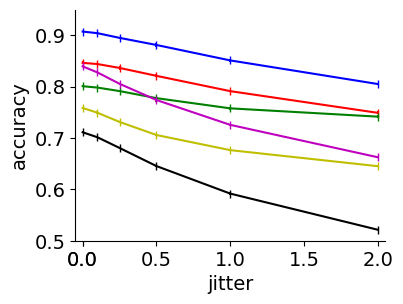

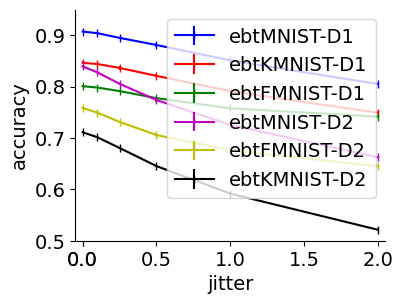

In [8]:
fig1 = plt.figure(1,figsize=(4,3))
plt.rcParams.update({'font.size': 14})
ax1=plt.gca()

fig2 = plt.figure(2,figsize=(4,3))
plt.rcParams.update({'font.size': 14})
ax2=plt.gca()

ds_LUT = {'20250724':{'ds':'MNIST', 'dist':'D1'},
          '20250803':{'ds':'FMNIST', 'dist':'D1'},
          '20250730_2':{'ds':'KMNIST', 'dist':'D1'},
          '20250809':{'ds':'MNIST', 'dist':'D2'},
          '20250810_2':{'ds':'FMNIST', 'dist':'D2'},
          '20250909':{'ds':'KMNIST', 'dist':'D2'}
         }

dss = np.sort(dfs['eb_ds_path'].unique())
datasets_list = [f'ebt{ds_LUT[data_path.split('/')[-1]]['ds']}-{ds_LUT[data_path.split('/')[-1]]['dist']}' for data_path in dss]

# jitter_vals = [0.0, 0.25, 0.50, 1.0, 2.0, 10]
jitter_vals = [0.0, 0.1, 0.25, 0.50, 1.0, 2.0]
# jitter_vals = [0.1, 0.25, 0.50, 1.0, 2.0]
plt_clr = ['b', 'r', 'g', 'm', 'y','k']
# plt_clr = [(0,0,1), (0,0,0.6), (0.4,0.4,1), (1,0,0), (0.6,0,0), (1,0.4,0.4)]
styles = ['-|', '--x',':d']
# fig,(ax1,ax2)=plt.subplots(1,2, figsize=(12,4))

table_rows = []

modes = []
# for tt, (this_mode, df_ds)  in enumerate(dfs.items()):
# Convert lists in 'ds_args_augment_per_event_shifts' to tuples
#     modes.append(this_mode)
dfs['ds_args_augment_per_event_shifts'] = dfs['ds_args_augment_per_event_shifts'].apply(tuple)

for aa,ax in enumerate([ax1,ax2]):
#     spike_counts = np.sort(df_ds['ds_args_n_samples'].unique())
#     dss = np.sort(dfs['eb_ds_path'].unique())
#     for ind, spike_cnt in enumerate(spike_counts):
    for ind, ds in enumerate(dss):
        df_slice = dfs[dfs['eb_ds_path'] == ds]
        df_grp = df_slice.groupby(['ds_args_augment_per_event_shifts']).aggregate({'seed':'count', 'test_acc':['mean','std','sem','count']})
        df_grp = df_grp.reindex([tuple([jit, 0, 0, 0]) for jit in jitter_vals])  # ensure the same order for plotting

        ax.errorbar(jitter_vals, df_grp['test_acc']['mean'], df_grp['test_acc']['std'], fmt=styles[0],
                    color=plt_clr[1*ind+0])
        
        ##
        df_to_csv = df_grp['test_acc'][['mean','std']].copy()
        df_to_csv.rename(columns={'mean': 'acc_mean', 'std': 'acc_std'}, inplace=True)
        df_to_csv.insert(0, "jitter", jitter_vals)
        panel = 'panelD'
        df_to_csv.to_csv(f'./figS1{panel}_{datasets_list[ind]}.csv', index=False)
        ##
        
        if aa == 0:
            for jj,this_jitter in enumerate(jitter_vals):
                table_rows.append(dict(eb_ds_path=ds, jitter=this_jitter,
                                   **{kk:df_grp['test_acc'][kk][jj] for kk in sorted(df_grp['test_acc'].keys())}
                                  ))

    # Get existing tick locations
    ticks = list(ax.get_xticks())
    new_tick_label_loc = jitter_vals[0]
    ticks.append(new_tick_label_loc)
#     # Map the positions to string labels
    labels = [str(t) for t in ticks]
    ax.set_xticks(ticks, labels=labels)
    ax.set_xlim(jitter_vals[0]-0.05, jitter_vals[-1]+0.05)
    
    ax.set_ylabel('accuracy')
    ax.set_xlabel('jitter')
    ax.spines[['right', 'top']].set_visible(False)
    
    
ax2.legend(datasets_list)#, title='spike count')
ax1.set_ylim([0.5, 0.95])
# ax2.set_ylim([1.00, 1.20])
# ax2.set_xlim([-0.02, 0.5])
ax2.set_ylim([0.5, 0.95])

fig1.savefig('jitter_all_ds.png', bbox_inches='tight')
fig2.savefig('jitter_all_ds_legend.png', bbox_inches='tight')
# # titles = [title+shade for title,shade in zip(modes,[' (pure)', ' (dark)', ' (light)'])]
# # add_inset_with_symbols(ax1, width="15%", height="15%", loc=3, styles=[uu+'k' for uu in styles], titles = titles,
                       # bbox=(0.25,0.15,0.5,0.5))
import matplotlib as mpl
mpl.rcParams['svg.fonttype'] = 'none' #for editable text in saved svg files
fig2.savefig('figS1panelD.svg', bbox_inches='tight')

In [31]:
jitter_vals
df_grp['test_acc']['mean']

ds_args_augment_per_event_shifts
(0.0, 0, 0, 0)         NaN
(0.1, 0, 0, 0)     0.70156
(0.25, 0, 0, 0)    0.68068
(0.5, 0, 0, 0)     0.64542
(1.0, 0, 0, 0)     0.59178
(2.0, 0, 0, 0)     0.52134
Name: mean, dtype: float64

In [7]:
!diff ../wexac_saved_runs/retest_mnist20p_augjit_920515_/config.yaml ../wexac_saved_runs/mnist20p_augjit617967_/config.yaml

3c3
< config_file: saved_runs/mnist20p_augjit617976_/config.yaml
---
> config_file: config/config_hA07.yaml
7a8
> - 0.0
11,12c12
< - 0
< ds_args_n_samples: 96
---
> ds_args_n_samples: 48
24c24
< epochs: 0
---
> epochs: 100
28,29c28,29
< json_log: ./saved_runs/retest_mnist20p_augjit_920515_/results/epoch_data.json
< json_test_data: ./saved_runs/retest_mnist20p_augjit_920515_/results/test_data.json
---
> json_log: ./saved_runs/mnist20p_augjit617967_/results/epoch_data.json
> json_test_data: ./saved_runs/mnist20p_augjit617967_/results/test_data.json
51,52c51,52
< pretrained_model_path: checkpoints/mnist20p_augjit617976_/models/last_model.t7
< run_name: retest_mnist20p_augjit_920515_
---
> pretrained_model_path: ''
> run_name: mnist20p_augjit617967_
56c56
< tag: retest_wo_aug_25_7
---
> tag: mnist20p_augjit


In [6]:
df_ds

,batch_size,check_job_recovery,config_file,dataset,disable_data_parallel,do_warmup,ds_args_augment_per_event_shifts,ds_args_n_samples,ds_args_one_hot_coordinates,ds_args_shuffle_events,...,save_path,seed,supervision_mode,train_head_only,use_sgd,epoch,test_loss,test_acc,test_avg_acc,test_time
ebtMNISTD1_20250724_jitter_tst_supervised_sweep_565197,64,True,saved_runs/acc_vs_jitter/jitter_test/ebtMNISTD...,eb_ds,False,True,"(0.25, 0, 0, 0)",48,False,False,...,./saved_runs/,46,supervised,False,False,[0],[0.35979622631073],0.8815,[0.8804471366278289],[1.1858375072479248]
ebtMNISTD1_20250724_jitter_tst_supervised_sweep_565169,64,True,saved_runs/acc_vs_jitter/jitter_test/ebtMNISTD...,eb_ds,False,True,"(2.0, 0, 0, 0)",48,False,False,...,./saved_runs/,43,supervised,False,False,[0],[2.253602813339233],0.4880,[0.4884674331166795],[1.6969635486602783]
ebtMNISTD1_20250724_96_supervised_sweep_582512,64,True,config/config_ebtMNISTD1_20250724_PTr.yaml,eb_ds,False,True,"(0, 0, 0, 0)",96,False,False,...,./saved_runs/,46,supervised,False,False,[0],[0.22037957721352577],0.9354,[0.9348162271858262],[0.6066329479217529]
ebtMNISTD1_20250724_jitter_tst_supervised_sweep_565209,64,True,saved_runs/acc_vs_jitter/jitter_test/ebtMNISTD...,eb_ds,False,True,"(0.5, 0, 0, 0)",96,False,False,...,./saved_runs/,42,supervised,False,False,[0],[0.4319896366596222],0.8837,[0.883672542834578],[1.0684783458709717]
ebtMNISTD1_20250724_jitter_tst_supervised_sweep_565232,64,True,saved_runs/acc_vs_jitter/jitter_test/ebtMNISTD...,eb_ds,False,True,"(1.0, 0, 0, 0)",96,False,False,...,./saved_runs/,44,supervised,False,False,[0],[1.079639317703247],0.7564,[0.757054275964072],[1.3844010829925537]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ebtMNISTD1_20250724_jitter_tst_supervised_sweep_565246,64,True,saved_runs/acc_vs_jitter/jitter_test/ebtMNISTD...,eb_ds,False,True,"(2.0, 0, 0, 0)",96,False,False,...,./saved_runs/,45,supervised,False,False,[0],[2.3041795310974122],0.5450,[0.5456635123852005],[1.5660746097564697]
ebtMNISTD1_20250724_96_supervised_sweep_582510,64,True,config/config_ebtMNISTD1_20250724_PTr.yaml,eb_ds,False,True,"(0, 0, 0, 0)",96,False,False,...,./saved_runs/,44,supervised,False,False,[0],[0.22398782312870025],0.9341,[0.9336421032505575],[0.6206095218658447]
ebtMNISTD1_20250724_jitter_tst_supervised_sweep_565240,64,True,saved_runs/acc_vs_jitter/jitter_test/ebtMNISTD...,eb_ds,False,True,"(0.25, 0, 0, 0)",96,False,False,...,./saved_runs/,45,supervised,False,False,[0],[0.2585353499889374],0.9225,[0.9219343403614003],[1.436934232711792]
ebtMNISTD1_20250724_jitter_tst_supervised_sweep_565218,64,True,saved_runs/acc_vs_jitter/jitter_test/ebtMNISTD...,eb_ds,False,True,"(0.25, 0, 0, 0)",96,False,False,...,./saved_runs/,43,supervised,False,False,[0],[0.2675528609752655],0.9222,[0.9218297092171351],[1.7728984355926514]


In [51]:
df_table = pd.DataFrame.from_dict(table_rows)
df_table

,eb_ds_path,jitter,count,mean,sem,std
0,../datasets/eb_datasets/20250730_2,0.00,NaN,NaN,NaN,NaN
1,../datasets/eb_datasets/20250730_2,0.10,5.0,0.84420,0.001234,0.002760
2,../datasets/eb_datasets/20250730_2,0.25,5.0,0.83660,0.001379,0.003083
3,../datasets/eb_datasets/20250730_2,0.50,5.0,0.82120,0.001269,0.002838
4,../datasets/eb_datasets/20250730_2,1.00,5.0,0.79138,0.001143,0.002555
5,../datasets/eb_datasets/20250730_2,2.00,5.0,0.74910,0.001301,0.002909
6,../datasets/eb_datasets/20250803,0.00,NaN,NaN,NaN,NaN
7,../datasets/eb_datasets/20250803,0.10,5.0,0.79832,0.000580,0.001297
8,../datasets/eb_datasets/20250803,0.25,5.0,0.79152,0.000462,0.001033
9,../datasets/eb_datasets/20250803,0.50,5.0,0.77774,0.000957,0.002141


In [9]:
print(
    df_to_latex_table(pd.DataFrame.from_dict(table_rows)[['mode', 'spike_count', 'jitter', 'count', 'mean', 'std', 'sem']],
                     column_formats={'spike_count':'.0f','count':'.0f'})
)

\begin{table}[ht]
\centering
\begin{tabular}{c | c | c | c | c | c | c}
\hline
\makecell{mode} & \makecell{spike_count} & \makecell{jitter} & \makecell{count} & \makecell{mean} & \makecell{std} & \makecell{sem} \\
\hline
jitter_both & 48 & 0.000 & 5 & 0.907 & 0.002 & 0.001 \\
\hline
jitter_both & 48 & 0.100 & 5 & 0.904 & 0.002 & 0.001 \\
\hline
jitter_both & 48 & 0.250 & 5 & 0.895 & 0.001 & 0.001 \\
\hline
jitter_both & 48 & 0.500 & 5 & 0.881 & 0.003 & 0.001 \\
\hline
jitter_both & 48 & 1.000 & 5 & 0.851 & 0.003 & 0.001 \\
\hline
jitter_both & 48 & 2.000 & 5 & 0.805 & 0.002 & 0.001 \\
\hline
jitter_both & 96 & 0.000 & 5 & 0.935 & 0.002 & 0.001 \\
\hline
jitter_both & 96 & 0.100 & 5 & 0.933 & 0.001 & 0.000 \\
\hline
jitter_both & 96 & 0.250 & 5 & 0.929 & 0.002 & 0.001 \\
\hline
jitter_both & 96 & 0.500 & 5 & 0.918 & 0.002 & 0.001 \\
\hline
jitter_both & 96 & 1.000 & 5 & 0.900 & 0.003 & 0.001 \\
\hline
jitter_both & 96 & 2.000 & 5 & 0.862 & 0.003 & 0.001 \\
\hline
jitter_training & 48 & 

In [28]:
table_rows[0].keys()

dict_keys(['mode', 'spike_count', 'jitter', 'count', 'mean', 'sem', 'std'])

## Calculating p-vlaues for EB with no jitter vs. EB with jitter using one-tailed wilcoxon rank-sum test

In [27]:
from scipy.stats import ranksums

def get_single_condition_acc(training_protocol, jitter, n_events):
    df_ds = dfs[condition]

    df_slice = df_ds[df_ds['ds_args_n_samples'] == n_events]
    df_slice['jitter'] = df_slice['ds_args_augment_per_event_shifts'].apply(lambda x: x[0])
    df_slice1 = df_slice[df_slice['jitter'] == jitter]
               
    sample = df_slice1['test_acc'].to_numpy()
    return sample

def wilcoxon_ranksum_test(sample1, sample2):
    # Null hypothesis: samples are drawn from the same distribution
    statistic, pvalue = ranksums(sample1, sample2, alternative='greater')

    return pvalue

n_events = 48 #96
jitter1=0.0
jitter2=0.25

condition = 'jitter_training'
sample1 = get_single_condition_acc(condition, jitter1, n_events)
sample2 = get_single_condition_acc(condition, jitter2, n_events)
pval =  wilcoxon_ranksum_test(sample1, sample2)
print(f'training protocol: {condition}, p-value: {pval}')

# condition = 'jitter_test'
# condition = 'jitter_both'

# df_ds = dfs[condition]

# df_slice = df_ds[df_ds['ds_args_n_samples'] == n_events]
# df_slice['jitter'] = df_slice['ds_args_augment_per_event_shifts'].apply(lambda x: x[0])
# df_slice1 = df_slice[df_slice['jitter'] == jitter1]
# df_slice2 = df_slice[df_slice['jitter'] == jitter2]
           
    
# sample1 = df_slice1['test_acc'].to_numpy()
# sample2 = df_slice2['test_acc'].to_numpy()

# print(sample1)
# print(sample2)

training protocol: jitter_training, p-value: 0.004511719409040163


/tmp/ipykernel_3994499/366413425.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_slice['jitter'] = df_slice['ds_args_augment_per_event_shifts'].apply(lambda x: x[0])
/tmp/ipykernel_3994499/366413425.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_slice['jitter'] = df_slice['ds_args_augment_per_event_shifts'].apply(lambda x: x[0])


In [25]:
from scipy.stats import ranksums

# Null hypothesis: samples are drawn from the same distribution
statistic, pvalue = ranksums(sample1, sample2, alternative='greater')

print(f"Rank-Sum Statistic: {statistic}, p-value: {pvalue}")

Rank-Sum Statistic: 2.6111648393354674, p-value: 0.004511719409040163
